# Meu Data Set de treinos 🏋🏻‍♂️
**Inicio do primeiro registro de treino 🚶🏻‍♂️‍➡️:**     
    *13 Mar 2023, 14:52*<br>
**Atual treino 🏃🏻‍♂️‍➡️:**    
    *30 Abr 2026, 21:27*<br>

In [35]:
import pandas as pd

## Investigando a base de dados

### Abaixo podemos ver algumas informações da nossa base de dados.

##### Colunas presentes no Data set

In [36]:
arquivo = 'workout_data.csv'
data = pd.read_csv(arquivo)
print("Nome das colunas:")
print(data.columns.tolist())



Nome das colunas:
['title', 'start_time', 'end_time', 'description', 'exercise_title', 'superset_id', 'exercise_notes', 'set_index', 'set_type', 'weight_kg', 'reps', 'distance_km', 'duration_seconds', 'rpe']


##### Estatística dos dados

In [37]:
print("Descrição estatística dos dados:")
print(data.describe())

Descrição estatística dos dados:
       description  superset_id     set_index     weight_kg          reps  \
count          0.0          0.0  14291.000000  13812.000000  13955.000000   
mean           NaN          NaN      1.983766     81.514052      7.637263   
std            NaN          NaN      1.730681     58.815347      5.139880   
min            NaN          NaN      0.000000      1.000000      1.000000   
25%            NaN          NaN      1.000000     32.000000      4.000000   
50%            NaN          NaN      2.000000     70.000000      8.000000   
75%            NaN          NaN      3.000000    110.000000     10.000000   
max            NaN          NaN     11.000000    470.000000     43.000000   

       distance_km  duration_seconds  rpe  
count    27.000000        309.000000  0.0  
mean      0.039259        392.326861  NaN  
std       0.003849        654.701404  NaN  
min       0.020000          1.000000  NaN  
25%       0.040000         38.000000  NaN  
50%      

##### Informações dos dados

In [38]:
print("Informações sobre os dados:")
print(data.info())


Informações sobre os dados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             14291 non-null  object 
 1   start_time        14291 non-null  object 
 2   end_time          14291 non-null  object 
 3   description       0 non-null      float64
 4   exercise_title    14291 non-null  object 
 5   superset_id       0 non-null      float64
 6   exercise_notes    668 non-null    object 
 7   set_index         14291 non-null  int64  
 8   set_type          14291 non-null  object 
 9   weight_kg         13812 non-null  float64
 10  reps              13955 non-null  float64
 11  distance_km       27 non-null     float64
 12  duration_seconds  309 non-null    float64
 13  rpe               0 non-null      float64
dtypes: float64(7), int64(1), object(6)
memory usage: 1.5+ MB
None


##### Contagem de series por cada exercício

In [39]:
print("Contagem de series de cada exercício:")
print(data['exercise_title'].value_counts())

Contagem de series de cada exercício:
exercise_title
Supino (Barra)                   1984
Agachamento (Barra)              1497
Levantamento Terra (Barra)       1408
Elevação Lateral (Halter)         744
Rosca Direta na Barra W           638
                                 ... 
Puxada Unilateral                   3
Remadas Iso-Lateral (Máquina)       3
Encolhimento (Halter)               3
Rosca Scott (Barra)                 3
Pec Deck                            3
Name: count, Length: 72, dtype: int64


##### Maior carga em KG de um exercicío.
**470kg**<br>
EXERCICÍO: Leg Press 

In [40]:
print(data['weight_kg'].max())


470.0


##### Criando coluna de volume de serie
coluna apenas disponivel no data set do notebook, não foi transportado para o arquivo .csv

In [41]:
data['volume_serie'] = data['weight_kg'] * data['reps']
print(data.columns.tolist())

['title', 'start_time', 'end_time', 'description', 'exercise_title', 'superset_id', 'exercise_notes', 'set_index', 'set_type', 'weight_kg', 'reps', 'distance_km', 'duration_seconds', 'rpe', 'volume_serie']


## Criando um Identificador para Cada Exercício
Para ter uma melhor consulta dos dados, e pesquisa, vamos criar um id para cada exercício.<br>
Vamos evitar casos como:<br>
    EXEMPLO:<br>
    `Em uma pesquisa de Top 10 erxercíco com maior volume de Série, retornar apenas leg press. Vamos pegar a melhor marca do exercício e vamos seguir para o próximo.`

In [48]:
print(data['exercise_title'].value_counts())

exercise_title
Supino (Barra)                   1984
Agachamento (Barra)              1497
Levantamento Terra (Barra)       1408
Elevação Lateral (Halter)         744
Rosca Direta na Barra W           638
                                 ... 
Puxada Unilateral                   3
Remadas Iso-Lateral (Máquina)       3
Encolhimento (Halter)               3
Rosca Scott (Barra)                 3
Pec Deck                            3
Name: count, Length: 72, dtype: int64


In [ ]:
data['id_exercise'] = data['exercise_title'].astype('category').cat.codes  # Criamos o ID!

# print(data['exercise_title'][data['id_exercise'] == 2])
# ===============  OUUU ========================
print(data.loc[data['id_exercise'] == 35, 'exercise_title']) 

# ACIMA ESTAMOS PRINTANDO O EXERCÍCIO BASEADO EM SEU ID!

106      Levantamento Terra (Barra)
107      Levantamento Terra (Barra)
108      Levantamento Terra (Barra)
109      Levantamento Terra (Barra)
110      Levantamento Terra (Barra)
                    ...            
14286    Levantamento Terra (Barra)
14287    Levantamento Terra (Barra)
14288    Levantamento Terra (Barra)
14289    Levantamento Terra (Barra)
14290    Levantamento Terra (Barra)
Name: exercise_title, Length: 1408, dtype: object


---

## Tabela auxiliar

Como vai ser feita mais de uma pesquisa do tipo: `top 10 maiores cargas por exercicío`, pensando em um cénario de BIG DATA, não é nada eficiente para cada pesquisa ficar procurando em 14 mil linhas de dados. Pensando neste problema o mais eficiente é criar uma **tabela auxiliar**, o que seria essa tabela?<br>
Vai ser uma tabela onde vai ser guardado: 
- Nome do exercicío;
- ID;
- maior carga;
- maior volume;
- maior numero de repetições e sua carga. 

In [84]:
tabela_auxiliar = data.groupby(by = 'id_exercise').agg({"exercise_title":"first","weight_kg": "max", "reps": "max", "volume_serie": "max",})
print(tabela_auxiliar)



                                                exercise_title  weight_kg  \
id_exercise                                                                 
0                                         Abdominal Na Máquina       85.0   
1                                        Abdominal Tradicional        NaN   
2            Aberturas Invertidas De Ombro Posterior (Na Má...      105.0   
3                                          Agachamento (Barra)      240.0   
4                                          Agachamento Búlgaro      100.0   
...                                                        ...        ...   
67                                      Supino No Chão (Barra)      140.0   
68                                       Triceps Testa (Barra)       45.0   
69                              Tríceps na Paralela (Com Peso)       24.0   
70                                            Tríceps na Polia       47.0   
71                                  Tríceps na Polia com Corda      283.0   

### Gráfico de top 5 maior volume de serie

In [42]:

import matplotlib.pyplot as plt

In [ ]:
top10 = data.nlargest(10, 'volume_serie')
print(top10)

                        title          start_time            end_time  \
2997   Treino b, full leg day   2 Out 2025, 19:08   2 Out 2025, 22:01   
9347                   Quarta   8 Ago 2024, 14:58   8 Ago 2024, 17:14   
9854                   Quarta  11 Jul 2024, 18:28  11 Jul 2024, 20:51   
10128                  Quarta  27 Jun 2024, 16:42  27 Jun 2024, 19:32   
10316                  Quarta  13 Jun 2024, 11:57  13 Jun 2024, 14:02   
3130   Treino b, full leg day  25 Set 2025, 19:04  25 Set 2025, 21:56   
9587                   Quarta  25 Jul 2024, 20:09  25 Jul 2024, 22:07   
9721                   Quarta  18 Jul 2024, 18:39  18 Jul 2024, 20:54   
2888   Treino b, full leg day   9 Out 2025, 21:50   9 Out 2025, 23:17   
2996   Treino b, full leg day   2 Out 2025, 19:08   2 Out 2025, 22:01   

       description           exercise_title  superset_id exercise_notes  \
2997           NaN  Leg Press 45º (Máquina)          NaN            NaN   
9347           NaN  Leg Press 45º (Máquina)   

In [44]:
y = top10['volume_serie']
x = [f"Leg press, {i+1}º" for i in range(len(y))]
print(x)

['Leg press, 1º', 'Leg press, 2º', 'Leg press, 3º', 'Leg press, 4º', 'Leg press, 5º', 'Leg press, 6º', 'Leg press, 7º', 'Leg press, 8º', 'Leg press, 9º', 'Leg press, 10º']


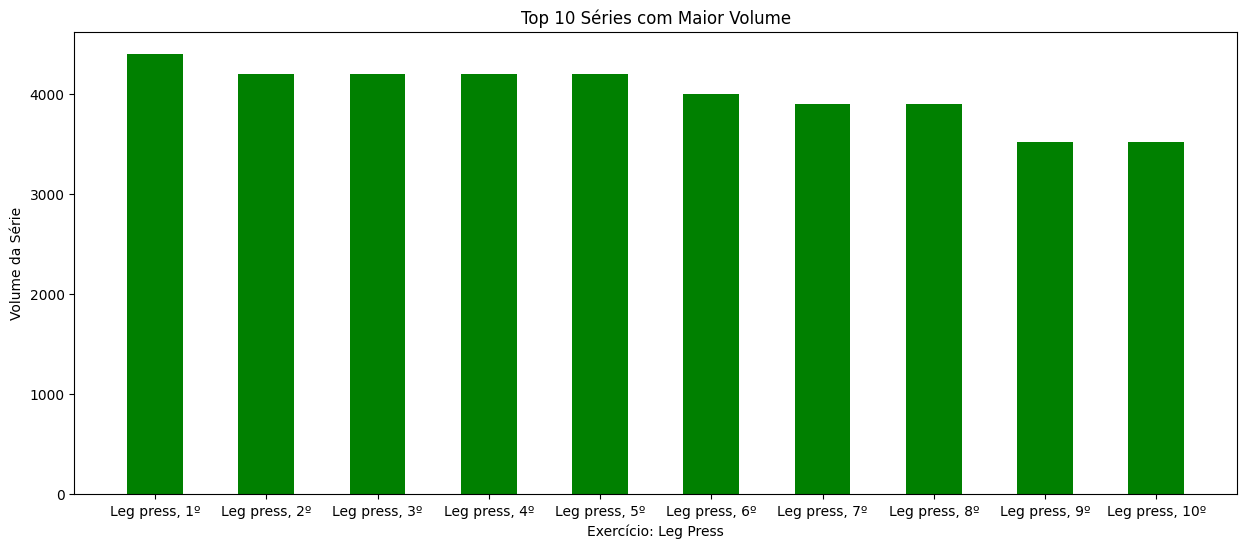

In [45]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar = plt.bar(x, y, color='green', width=0.5)
ax.set_xlabel('Exercício: Leg Press')
ax.set_ylabel('Volume da Série')
ax.set_title('Top 10 Séries com Maior Volume')

plt.show()

#### Conclusão
ao limpar valores fora do comum de repetições feitas, muito provavel tenha ocorrido algum erro ao digitar a serie, checamos o top 10 exercícios com mais repetições, e podemos ver que o campeão é o leg press 45° (máquina) por ser um exercicío de carga livre e um auxiliar dos meus treinos de powerlifting, foi capaz de conseguir fazer grande número de repetições com uma carga considerada.

---

## Top 10 exercicio com melhores cargas de serie

In [46]:
top10_kg = data.nlargest(10, 'weight_kg')
print(top10_kg['weight_kg'])

10449    470.0
10448    450.0
9857     400.0
10130    400.0
10131    400.0
10318    400.0
10319    400.0
10447    400.0
10579    400.0
10580    400.0
Name: weight_kg, dtype: float64
